In [2]:
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import rasterio.plot
import matplotlib.pyplot as plt
import numpy as np

In [3]:
ruta_carbono = r"Maps_Carbono_Stock_tambo.tif"
ruta_dry_weight = r"mapa_DRY_WEIGHT_1.tif"
ruta_erosion = r"A_erosion_2024_clip.tif"
ruta_clasi = r"Clasificacion_Tambo.tif"

Cargando 4 mapas...

Cargando y mostrando: Carbono Stock...
  > Resolución de píxel: 10.0000 x 10.0000 metre
  > Percentiles:
     min: -6.3398
      p5: 108.4584
     p25: 151.3810
     p50: 178.9290
     p75: 214.5983
     p95: 282.8384
     max: 526.2068

Cargando y mostrando: Dry Weight (Biomasa)...
  > Resolución de píxel: 10.0000 x 10.0000 metre
  > Percentiles:
     min: 0.1871
      p5: 47.5350
     p25: 85.1176
     p50: 111.7052
     p75: 134.6210
     p95: 173.9073
     max: 260.5721

Cargando y mostrando: Erosión Potencial...
  > Resolución de píxel: 10.0000 x 10.0000 metre
  > Percentiles:
     min: 0.1214
      p5: 9.6795
     p25: 31.2628
     p50: 78.2189
     p75: 170.8364
     p95: 375.6610
     max: 3167.7622

Cargando y mostrando: Clasificacion_Pastizal...
  > Resolución de píxel: 10.0000 x 10.0000 metre
  > Valores únicos: [1. 2. 3. 4.]


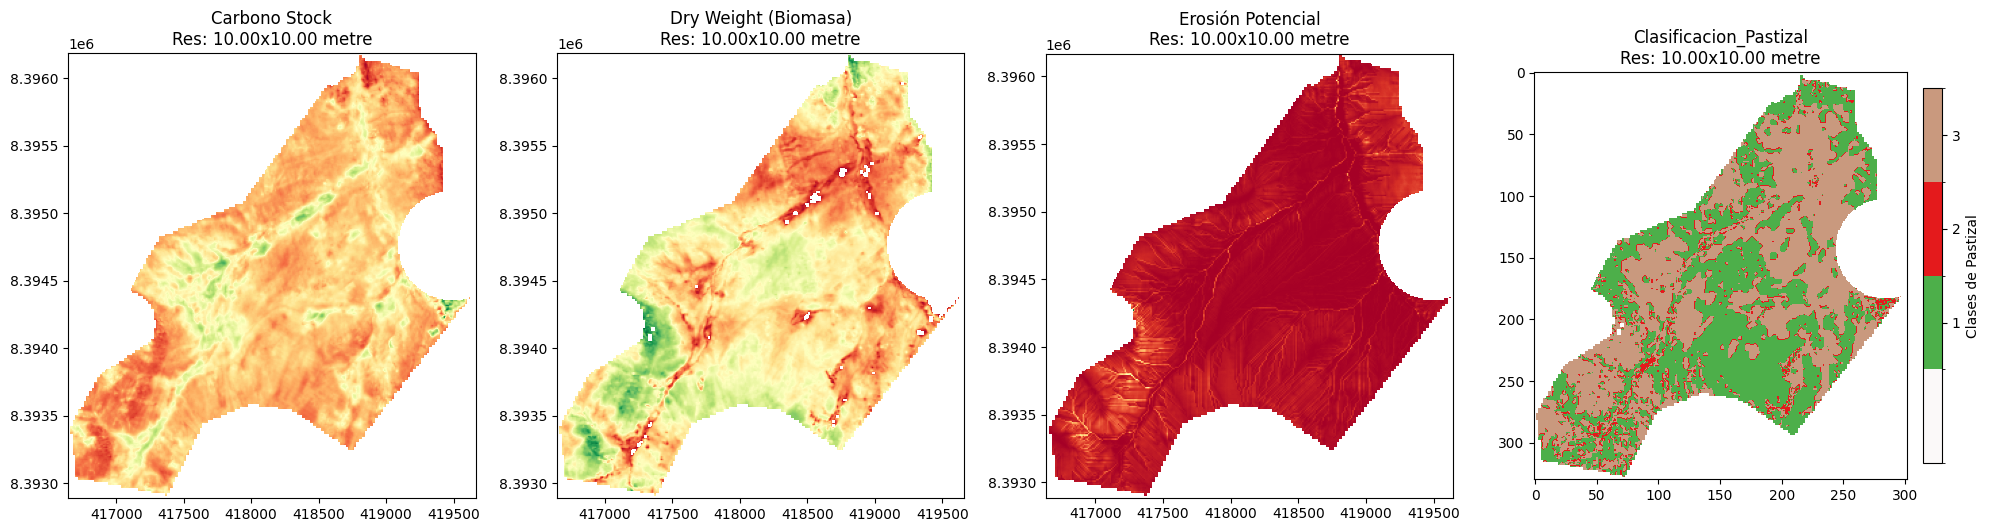


Visualización completada.


In [6]:
from matplotlib.colors import ListedColormap, BoundaryNorm
mapas_a_cargar = [
    {"titulo": "Carbono Stock", "ruta": ruta_carbono},
    {"titulo": "Dry Weight (Biomasa)", "ruta": ruta_dry_weight},
    {"titulo": "Erosión Potencial", "ruta": ruta_erosion},
    {"titulo": "Clasificacion_Pastizal", "ruta": ruta_clasi},  # Añade más mapas si es necesario
]

# --- 2. CONFIGURAR LA VISUALIZACIÓN ---
# Crearemos una figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

print(f"Cargando {len(mapas_a_cargar)} mapas...")

# --- 3. CARGAR Y VISUALIZAR CADA MAPA ---
# --- 3. CARGAR Y VISUALIZAR ---
for i, mapa_info in enumerate(mapas_a_cargar):
    ax = axes[i]
    try:
        with rasterio.open(mapa_info["ruta"]) as src:
            print(f"\nCargando y mostrando: {mapa_info['titulo']}...")
            xres, yres = src.res
            print(f"  > Resolución de píxel: {xres:.4f} x {yres:.4f} {src.crs.linear_units}")

            datos = src.read(1).astype(float)
            datos = np.where(datos == src.nodata, np.nan, datos)

            # --- CLASIFICACIÓN (nominal) ---
            if "clasificacion" in mapa_info["titulo"].lower():
                valores_unicos = np.unique(datos[~np.isnan(datos)])
                print(f"  > Valores únicos: {valores_unicos}")

                # Paleta discreta
                colores = ["#fbf9f9", "#4daf4a","#e41a1c", "#c69275ee", "#0d00ff"]
                cmap = ListedColormap(colores[:len(valores_unicos)])
                bounds = np.arange(len(valores_unicos) + 1) - 0.5
                norm = BoundaryNorm(bounds, cmap.N)

                img = ax.imshow(datos, cmap=cmap, norm=norm)
                cbar = plt.colorbar(img, ax=ax, ticks=valores_unicos, fraction=0.046, pad=0.04)
                cbar.ax.set_yticklabels([str(int(v)) for v in valores_unicos])
                cbar.set_label("Clases de Pastizal")

                ax.set_title(f"{mapa_info['titulo']}\nRes: {xres:.2f}x{yres:.2f} {src.crs.linear_units}")

            # --- CONTINUOS (biofísicos) ---
            else:
                # Calcular percentiles
                validos = datos[~np.isnan(datos)]
                percentiles = np.nanpercentile(validos, [0, 5, 25, 50, 75, 95, 100])
                p_labels = ["min", "p5", "p25", "p50", "p75", "p95", "max"]
                p_dict = dict(zip(p_labels, percentiles))
                print("  > Percentiles:")
                for k, v in p_dict.items():
                    print(f"    {k:>4}: {v:.4f}")

                # Mostrar raster
                rasterio.plot.show(src, ax=ax, cmap='RdYlGn')
                ax.set_title(f"{mapa_info['titulo']}\nRes: {xres:.2f}x{yres:.2f} {src.crs.linear_units}")

    except Exception as e:
        print(f"ERROR: No se pudo cargar el mapa '{mapa_info['titulo']}' desde: {mapa_info['ruta']}")
        print(f"Detalle del error: {e}")
        ax.set_title(f"ERROR AL CARGAR\n{mapa_info['titulo']}", color='red')
        ax.set_facecolor('lightgray')

# --- 4. MOSTRAR EL PLOT ---
plt.savefig("Indices_multiples_y_clasi.png", dpi=300)
plt.tight_layout()
plt.show()

print("\nVisualización completada.")

In [43]:
import numpy as np
import rasterio
from rasterio.enums import Resampling
import pandas as pd
mapas_a_cargar = [
    {"titulo": "Carbono Stock", "ruta": ruta_carbono},
    {"titulo": "Dry Weight (Biomasa)", "ruta": ruta_dry_weight},
    {"titulo": "Erosión Potencial", "ruta": ruta_erosion},
    {"titulo": "Clasificacion_Pastizal", "ruta": ruta_clasi},  # Añade más mapas si es necesario
]
output_index = r"Indice_Pastizal_Tambo.tif"
def read_and_match(ref_path, other_path):
    with rasterio.open(ref_path) as ref:
        ref_meta = ref.meta.copy()
        with rasterio.open(other_path) as src:
            data = src.read(
                1,
                out_shape=(ref.height, ref.width),
                resampling=Resampling.bilinear
            )
    return data, ref_meta

# ==========================
# 🔹 1. LECTURA DE DATOS
# ==========================
erosion, meta = read_and_match(ruta_dry_weight, ruta_erosion)
carbono, _ = read_and_match(ruta_dry_weight, ruta_carbono)
dry, _ = read_and_match(ruta_dry_weight, ruta_dry_weight)
# Limpieza
mask_invalid = (erosion <= 0) | (carbono <= 0) | (dry <= 0)
erosion[mask_invalid] = np.nan
carbono[mask_invalid] = np.nan
dry[mask_invalid] = np.nan

# ==========================
# 🔹 2. NORMALIZACIÓN ROBUSTA (usando percentiles)
# ==========================
def robust_minmax(arr, low=2, high=98):
    """Normaliza un array entre 0–1 usando percentiles para evitar outliers."""
    valid = arr[~np.isnan(arr)]
    p_low, p_high = np.nanpercentile(valid, [low, high])
    norm = (arr - p_low) / (p_high - p_low)
    return np.clip(norm, 0, 1)

C_norm = robust_minmax(carbono)
D_norm = robust_minmax(dry)
E_norm = 1 - robust_minmax(erosion)  # invertido: menos erosión = mejor

# ==========================
# 🔹 3. ÍNDICE COMPUESTO
# ==========================
wC, wD, wE = 1, 1, 1
index = (wC * C_norm + wD * D_norm + wE * E_norm) / (wC + wD + wE)

# ==========================
# 🔹 4. GUARDAR RASTER
# ==========================
meta.update(dtype=rasterio.float32, count=1)
with rasterio.open(output_index, "w", **meta) as dst:
    dst.write(index.astype(rasterio.float32), 1)

print(f"\n✅ Índice de Pastizal guardado en: {output_index}")

# ==========================
# 🔹 5. ESTADÍSTICAS
# ==========================
print("\nEstadísticas del índice:")
print(f"  Min: {np.nanmin(index):.3f}")
print(f"  Mediana: {np.nanmedian(index):.3f}")
print(f"  Max: {np.nanmax(index):.3f}")

# Clasificación opcional (si quieres categorías)
bins = [0, 0.2, 0.4, 0.6, 0.8, 1]
labels = ["Muy degradado", "Degradado", "Moderado", "Bueno", "Excelente"]
clas = np.digitize(index, bins) - 1
clas = np.where(np.isnan(index), np.nan, clas)



✅ Índice de Pastizal guardado en: Indice_Pastizal_Tambo.tif

Estadísticas del índice:
  Min: 0.135
  Mediana: 0.565
  Max: 0.881


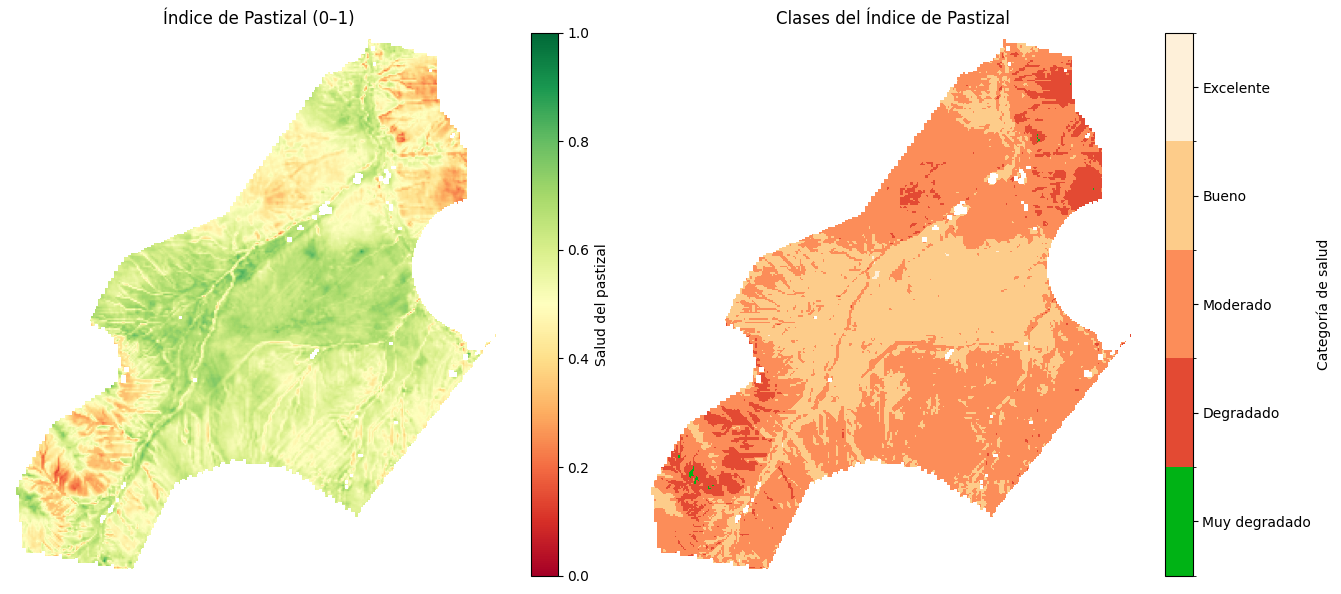

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# --- 1. LEER EL RASTER DEL ÍNDICE ---
ruta_indice = "Indice_Pastizal_Tambo.tif"

with rasterio.open(ruta_indice) as src:
    index = src.read(1)
    meta = src.meta.copy()

# --- 2. CLASIFICACIÓN OPCIONAL ---
bins = [0, 0.2, 0.4, 0.6, 0.8, 1]
labels = ["Muy degradado", "Degradado", "Moderado", "Bueno", "Excelente"]
clas = np.digitize(index, bins) - 1
clas = np.where(np.isnan(index), np.nan, clas)

# --- 3. CONFIGURAR FIGURA ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- MAPA CONTINUO ---
im1 = axes[0].imshow(index, cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_title("Índice de Pastizal (0–1)")
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label("Salud del pastizal")

# --- MAPA CLASIFICADO ---
colores = ["#00b315", "#e34a33", "#fc8d59", "#fdcc8a", "#fef0d9"]  # degradado → excelente
cmap = ListedColormap(colores)
bounds = np.arange(len(labels) + 1) - 0.5
norm = BoundaryNorm(bounds, cmap.N)
im2 = axes[1].imshow(clas, cmap=cmap, norm=norm)
axes[1].set_title("Clases del Índice de Pastizal")

# --- BARRA DE COLORES CON ETIQUETAS ---
cbar2 = plt.colorbar(im2, ax=axes[1], ticks=np.arange(len(labels)), fraction=0.046, pad=0.04)
cbar2.ax.set_yticklabels(labels)
cbar2.set_label("Categoría de salud")

# --- ESTILO GENERAL ---
for ax in axes:
    ax.axis("off")
plt.savefig("Visualizacion_Indice_Pastizal.png", dpi=300)
plt.tight_layout()
plt.show()


📍 Distancia Line Tambo
  - Shape: (329, 320)
  - No. píxeles válidos: 53418
  - Valor mínimo: 0.0263
  - Valor máximo: 1569.4075
  - Media: 743.2171
  - Desviación estándar: 400.1952

📍 Distancia a Líneas
  - Shape: (1928, 1880)
  - No. píxeles válidos: 1837521
  - Valor mínimo: 0.0013
  - Valor máximo: 4492.4927
  - Media: 1498.5652
  - Desviación estándar: 1035.3458


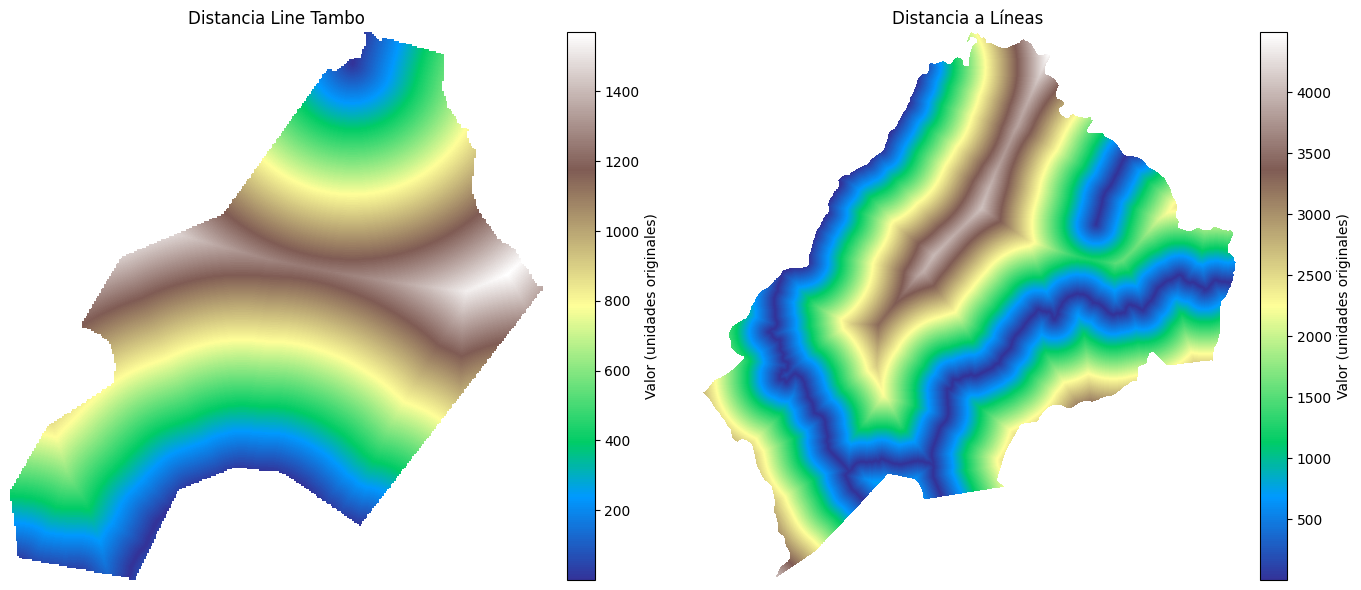

In [47]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# --- 1. Load both rasters ---
paths = {
    "Distancia Line Tambo": "distancia_line_tambo.tif",
    "Distancia a Líneas": "distancia_a_lineas.tif"
}

maps = {}
for title, path in paths.items():
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        data = np.where(data == nodata, np.nan, data)
        maps[title] = data
        print(f"\n📍 {title}")
        print(f"  - Shape: {data.shape}")
        print(f"  - No. píxeles válidos: {np.isfinite(data).sum()}")
        print(f"  - Valor mínimo: {np.nanmin(data):.4f}")
        print(f"  - Valor máximo: {np.nanmax(data):.4f}")
        print(f"  - Media: {np.nanmean(data):.4f}")
        print(f"  - Desviación estándar: {np.nanstd(data):.4f}")

# --- 2. Plot both rasters ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (title, arr) in zip(axes, maps.items()):
    im = ax.imshow(arr, cmap='terrain', norm=Normalize(vmin=np.nanmin(arr), vmax=np.nanmax(arr)))
    ax.set_title(title)
    ax.axis("off")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Valor (unidades originales)")

plt.tight_layout()
plt.show()
